## Langchain Version v1

# Agents

In [1]:
import langchain
import langchain_openai
langchain.__version__

'1.3.2'

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

print(os.getenv("OPENAI_API_KEY")[:12])

sk-proj-Ek7A


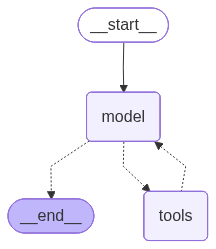

In [16]:
from langchain_core import tools
from langchain.agents import create_agent

def Ai_writer(content:str)-> str:
    """write some content about rag"""
    return f"rag always promote {content}"

agent = create_agent(
    model="gpt-5",
    tools=[Ai_writer],
    system_prompt = " you are a helpfull teqnical writer"
)
agent

In [15]:
### run the agent
response=agent.invoke({"messages":[{"role":"user","content":"What is rag?"}]})

In [23]:
response["messages"][-1].content

'RAG (Retrieval-Augmented Generation) is a technique for large language models that combines search with generation. Instead of relying only on what the model learned during training, RAG retrieves relevant external documents at query time and feeds them to the model so it can produce answers grounded in that evidence.\n\nHow it works (typical pipeline)\n- Ingest and index: Split your documents into chunks, embed them into vectors, and store them in a vector database alongside metadata.\n- Retrieve: For a user query, generate a vector for the query and fetch the top-K most similar chunks (often with filters and optional re-ranking).\n- Augment: Build a prompt that includes the user’s question plus the retrieved passages.\n- Generate: The LLM writes an answer that cites or is constrained by the retrieved context.\n- (Optional) Post-process: Add citations, verify sources, or route follow-ups.\n\nWhy use it\n- Improves factual accuracy and reduces hallucinations by grounding outputs in so

In [25]:
agent.invoke({"messages":"what is use of rag?"})

{'messages': [HumanMessage(content='what is use of rag?', additional_kwargs={}, response_metadata={}, id='d777460c-320c-4a18-891f-46dd3c6c0b2d'),
  AIMessage(content='RAG (Retrieval-Augmented Generation) is a design pattern for large language models that improves factuality and domain relevance by letting the model “look up” information from external sources at query time and then generate an answer grounded in what it retrieved.\n\nWhy use RAG\n- Up-to-date knowledge without retraining the model\n- More factual answers and fewer hallucinations\n- Grounded outputs with citations or source snippets\n- Domain-specific Q&A over your own documents, wikis, PDFs, databases, or APIs\n- Better privacy and governance (you control what the model can reference)\n- Lower cost than fine-tuning for many knowledge tasks\n- Works well with smaller/base models by injecting high-quality context\n- Easier iteration: update the index instead of re-training\n\nCommon use cases\n- Customer support over manu